### Standard LSTM Model with feature engineered data - KFold and Optuna hyperparameter tuning

In [18]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import optuna
import lime.lime_tabular
import lime.lime_tabular as lime
import shap
from IPython.display import display, HTML

tf.compat.v1.enable_eager_execution()

In [2]:
DATA_PATH = '/Users/amalshar/Desktop/USD/Fall 2025/Data Analysis/Final Project/daily_2025_engineered_data.csv'

GROUP_COLS = ['State Code', 'County Code', 'Site Num']
BASE_FEATURES = ['CO', 'SO2', 'NO2', 'O3', 'PM25',
                 'BarometricPressure', 'Temperature', 'WindResultant']

ENG_FEATURES = [
    'AQI_lag_1','AQI_lag_3','AQI_lag_7',
    'AQI_roll_3','AQI_roll_7',
    'CO_roll_3','CO_roll_7','NO2_roll_3','NO2_roll_7',
    'PM25_roll_3','PM25_roll_7','O3_roll_3','O3_roll_7',
    'month','dayofweek','is_weekend','dayofyear',
    'PM25xTemp','NO2xWind'
]

TARGET = 'DailyAQI'
FEATURES = BASE_FEATURES + ENG_FEATURES

TIME_STEPS = 30
USE_LOG_TARGET = True

df = pd.read_csv(DATA_PATH)
df['Date Local'] = pd.to_datetime(df['Date Local'], errors='coerce')

# sort by location + time
df = df.sort_values(GROUP_COLS + ['Date Local']).reset_index(drop=True)

needed_cols = GROUP_COLS + ['Date Local'] + FEATURES + [TARGET]
df = df.dropna(subset=needed_cols).copy()

print("Rows after cleaning:", len(df))
print("Date range:", df['Date Local'].min(), "->", df['Date Local'].max())
print("Unique sites:", df[GROUP_COLS].drop_duplicates().shape[0])


Rows after cleaning: 91740
Date range: 2025-01-01 00:00:00 -> 2025-07-01 00:00:00
Unique sites: 341


In [3]:
X_raw = df[FEATURES].values
y_raw = df[[TARGET]].values

# optional log1p on target
if USE_LOG_TARGET:
    y_t = np.log1p(y_raw)
else:
    y_t = y_raw

# feature scaler (fit on full history for tuning; later we will refit on train only)
scaler_X_global = MinMaxScaler().fit(X_raw)
X_s_all = scaler_X_global.transform(X_raw)

# robust target scaler
scaler_y_global = RobustScaler().fit(y_t)
y_s_all = scaler_y_global.transform(y_t)

# attach back to dataframe for group-wise sequence creation
df_s = df[GROUP_COLS + ['Date Local']].copy()
for i, col in enumerate(FEATURES):
    df_s[col] = X_s_all[:, i]
df_s['y_s'] = y_s_all

print(df_s.head())


   State Code  County Code  Site Num Date Local        CO       SO2       NO2  \
0           6           19        11 2025-01-01  0.174509  0.042329  0.255184   
1           6           19        11 2025-01-01  0.174509  0.042329  0.255184   
2           6           19        11 2025-01-01  0.174509  0.042329  0.255184   
3           6           19        11 2025-01-01  0.174509  0.042452  0.255184   
4           6           19        11 2025-01-01  0.154270  0.042452  0.255184   

        O3      PM25  BarometricPressure  ...  PM25_roll_7  O3_roll_3  \
0  0.16921  0.238349            0.875587  ...     0.321546   0.181371   
1  0.16921  0.260497            0.875587  ...     0.321546   0.181371   
2  0.16921  0.260497            0.875587  ...     0.321546   0.181371   
3  0.16921  0.238037            0.875587  ...     0.321487   0.181371   
4  0.16921  0.260497            0.875587  ...     0.325647   0.181371   

   O3_roll_7  month  dayofweek  is_weekend  dayofyear  PM25xTemp  NO2xWind

In [4]:
def build_sequences_by_group(frame, features, target_col, time_steps, group_cols):
    """
    Create [num_samples, time_steps, num_features] and [num_samples, 1]
    by sliding a window within each (state, county, site) group.
    """
    Xs, ys = [], []
    for _, g in frame.groupby(group_cols, sort=False):
        g = g.sort_values('Date Local')
        Xg = g[features].values
        yg = g[[target_col]].values
        if len(g) <= time_steps:
            continue
        for i in range(len(g) - time_steps):
            Xs.append(Xg[i:i+time_steps])
            ys.append(yg[i+time_steps])
    return np.array(Xs), np.array(ys)

X_seq_all, y_seq_all = build_sequences_by_group(
    df_s, FEATURES, 'y_s', TIME_STEPS, GROUP_COLS
)

print("Sequence shapes:", X_seq_all.shape, y_seq_all.shape)


Sequence shapes: (81615, 30, 27) (81615, 1)


In [5]:
# keep last 20% of sequences as final test set
n_total = X_seq_all.shape[0]
test_size = int(0.2 * n_total)

X_trainval = X_seq_all[:-test_size]
y_trainval = y_seq_all[:-test_size]

X_test = X_seq_all[-test_size:]
y_test = y_seq_all[-test_size:]

print("Train+Val:", X_trainval.shape, y_trainval.shape)
print("Test:", X_test.shape, y_test.shape)


Train+Val: (65292, 30, 27) (65292, 1)
Test: (16323, 30, 27) (16323, 1)


In [6]:
def build_lstm_model(n_features,
                     time_steps,
                     n_units1=64,
                     n_units2=32,
                     dropout_rate=0.2,
                     bidirectional=True,
                     lr=1e-3):
    model = Sequential()
    
    if bidirectional:
        model.add(Input(shape=(time_steps, n_features)))
        model.add(Bidirectional(LSTM(n_units1, return_sequences=True)))
    else:
        model.add(Input(shape=(time_steps, n_features)))
        model.add(LSTM(n_units1, return_sequences=True))
    
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(LSTM(n_units2))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )
    return model


In [7]:
N_SPLITS = 3      # time-series folds
N_TRIALS = 20     # number of Optuna trials (increase if you have time)

def inverse_target(y_scaled):
    """Invert both RobustScaler and optional log1p."""
    y_inv = scaler_y_global.inverse_transform(y_scaled)
    if USE_LOG_TARGET:
        y_inv = np.expm1(y_inv)
    return y_inv

def objective(trial):
    # hyperparameter search space
    n_units1 = trial.suggest_int('n_units1', 32, 128, step=32)
    n_units2 = trial.suggest_int('n_units2', 16, 96, step=16)
    dropout  = trial.suggest_float('dropout', 0.1, 0.4)
    lr       = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    bidir    = trial.suggest_categorical('bidirectional', [True, False])
    batch_sz = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs   = trial.suggest_int('epochs', 25, 60)
    
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    rmses = []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval)):
        X_tr, X_val = X_trainval[train_idx], X_trainval[val_idx]
        y_tr, y_val = y_trainval[train_idx], y_trainval[val_idx]
        
        model = build_lstm_model(
            n_features=len(FEATURES),
            time_steps=TIME_STEPS,
            n_units1=n_units1,
            n_units2=n_units2,
            dropout_rate=dropout,
            bidirectional=bidir,
            lr=lr
        )
        
        es = EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=0
        )
        rlrop = ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0
        )
        
        model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_sz,
            callbacks=[es, rlrop],
            verbose=0
        )
        
        # predictions (still in scaled target space)
        y_val_pred_s = model.predict(X_val, verbose=0)
        
        # invert to original AQI scale for metric
        y_val_pred = inverse_target(y_val_pred_s)
        y_val_true = inverse_target(y_val)
        
        rmse = np.sqrt(mean_squared_error(y_val_true, y_val_pred))
        rmses.append(rmse)
    
    mean_rmse = float(np.mean(rmses))
    print(f"Trial {trial.number}: mean CV RMSE = {mean_rmse:.3f}")
    return mean_rmse


In [8]:
study = optuna.create_study(direction='minimize', study_name='lstm_aqi_feature_engineered')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best trial:")
print("  RMSE:", study.best_value)
print("  Params:", study.best_params)


[I 2025-11-25 15:51:21,462] A new study created in memory with name: lstm_aqi_feature_engineered
Best trial: 0. Best value: 10.1467:   5%|▌         | 1/20 [25:46<8:09:35, 1546.07s/it]

Trial 0: mean CV RMSE = 10.147
[I 2025-11-25 16:17:07,587] Trial 0 finished with value: 10.146661065427415 and parameters: {'n_units1': 96, 'n_units2': 32, 'dropout': 0.20369260037396955, 'lr': 0.002496746713423086, 'bidirectional': True, 'batch_size': 128, 'epochs': 56}. Best is trial 0 with value: 10.146661065427415.


Best trial: 0. Best value: 10.1467:  10%|█         | 2/20 [36:38<5:06:06, 1020.38s/it]

Trial 1: mean CV RMSE = 10.582
[I 2025-11-25 16:27:59,984] Trial 1 finished with value: 10.58214862502491 and parameters: {'n_units1': 64, 'n_units2': 64, 'dropout': 0.19358451143240327, 'lr': 0.0017041657068537148, 'bidirectional': False, 'batch_size': 256, 'epochs': 38}. Best is trial 0 with value: 10.146661065427415.


Best trial: 0. Best value: 10.1467:  15%|█▌        | 3/20 [56:01<5:07:36, 1085.67s/it]

...

Trial 17: mean CV RMSE = 10.491
[I 2025-11-26 02:25:55,717] Trial 17 finished with value: 10.491224831120038 and parameters: {'n_units1': 96, 'n_units2': 48, 'dropout': 0.24033783698686764, 'lr': 0.0014767544490412732, 'bidirectional': False, 'batch_size': 64, 'epochs': 25}. Best is trial 11 with value: 9.825442460914157.


Best trial: 11. Best value: 9.82544:  95%|█████████▌| 19/20 [11:58:52<57:44, 3464.20s/it]  

Trial 18: mean CV RMSE = 10.050
[I 2025-11-26 03:50:13,829] Trial 18 finished with value: 10.050328084410332 and parameters: {'n_units1': 128, 'n_units2': 64, 'dropout': 0.31315874825225243, 'lr': 0.003151343300608725, 'bidirectional': True, 'batch_size': 128, 'epochs': 33}. Best is trial 11 with value: 9.825442460914157.


Best trial: 11. Best value: 9.82544: 100%|██████████| 20/20 [13:04:56<00:00, 2354.80s/it]

Trial 19: mean CV RMSE = 10.656
[I 2025-11-26 04:56:17,511] Trial 19 finished with value: 10.65649826316225 and parameters: {'n_units1': 96, 'n_units2': 96, 'dropout': 0.22511775233827905, 'lr': 0.0007865146361101321, 'bidirectional': False, 'batch_size': 128, 'epochs': 44}. Best is trial 11 with value: 9.825442460914157.
Best trial:
  RMSE: 9.825442460914157
  Params: {'n_units1': 128, 'n_units2': 96, 'dropout': 0.24595845722424856, 'lr': 0.004688076257491556, 'bidirectional': False, 'batch_size': 64, 'epochs': 30}


{'n_units1': 128, 'n_units2': 96, 'dropout': 0.24595845722424856, 'lr': 0.004688076257491556, 'bidirectional': False, 'batch_size': 64, 'epochs': 30}
Epoch 1/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 99s 103ms/step - loss: 0.1365 - mae: 0.3699 - val_loss: 0.6388 - val_mae: 1.0080 - learning_rate: 0.0047
Epoch 2/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 89s 97ms/step - loss: 0.1036 - mae: 0.3112 - val_loss: 0.2696 - val_mae: 0.6163 - learning_rate: 0.0047
Epoch 3/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 93s 101ms/step - loss: 0.1040 - mae: 0.3102 - val_loss: 0.5021 - val_mae: 0.8795 - learning_rate: 0.0047
Epoch 4/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 93s 101ms/step - loss: 0.1048 - mae: 0.3120 - val_loss: 0.1595 - val_mae: 0.4160 - learning_rate: 0.0047
Epoch 5/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 96s 105ms/step - loss: 0.0985 - mae: 0.3007 - val_loss: 0.1994 - val_mae: 0.5166 - learning_rate: 0.0047
Epoch 6/30
919/919 ━━━━━━━━━━━━━━━━━━━━ 101s 110ms/step - loss: 0.0922 - mae: 0.2880 - val_loss: 0.3500 - val_mae: 0.7570 - le

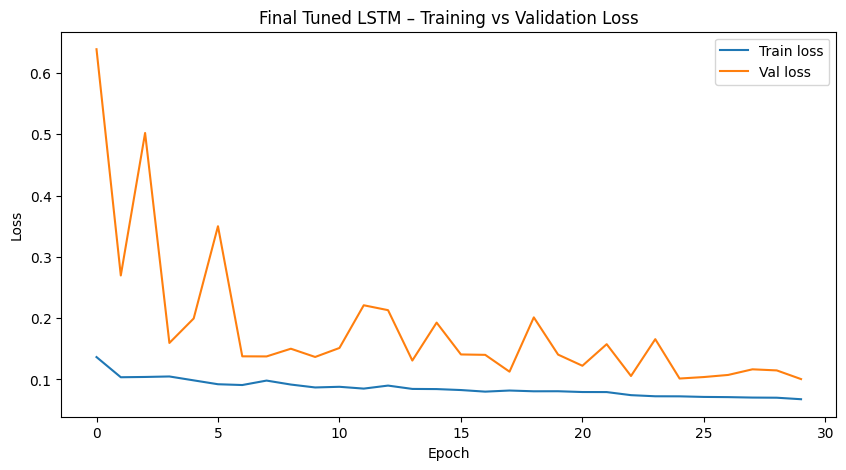

In [9]:
best_params = study.best_params
print(best_params)

final_model = build_lstm_model(
    n_features=len(FEATURES),
    time_steps=TIME_STEPS,
    n_units1=best_params['n_units1'],
    n_units2=best_params['n_units2'],
    dropout_rate=best_params['dropout'],
    bidirectional=best_params['bidirectional'],
    lr=best_params['lr']
)

es_final = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
rlrop_final = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)

history = final_model.fit(
    X_trainval, y_trainval,
    validation_split=0.1,          # small split within train+val for monitoring
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    callbacks=[es_final, rlrop_final],
    verbose=1
)

# %%
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Final Tuned LSTM – Training vs Validation Loss')
plt.legend()
plt.show()


511/511 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step
Tuned LSTM on Test Set -> MSE: 13256.738 | RMSE: 115.138 | MAE: 15.351 | MAPE: 12179507.38% | R²: -2.429


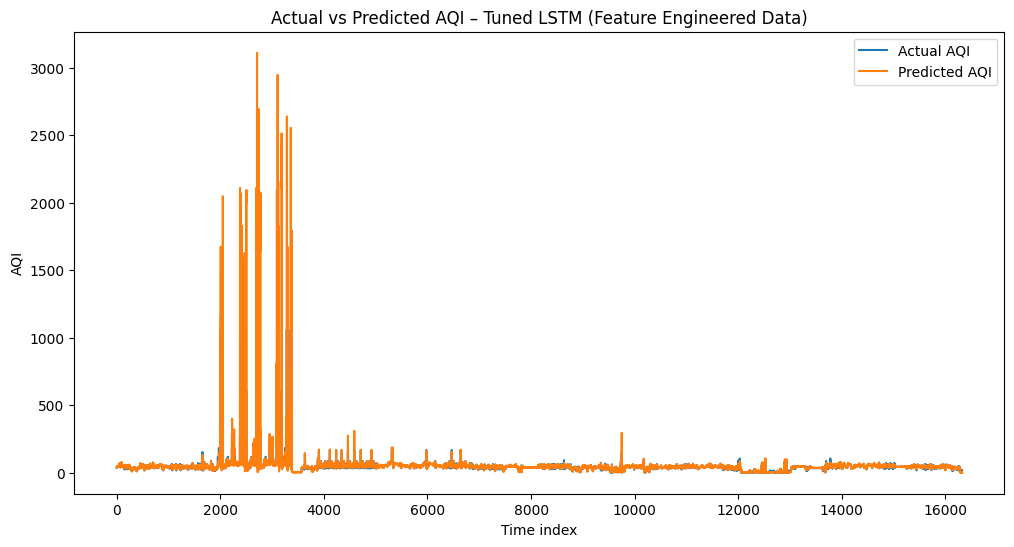

In [10]:
y_test_pred_s = final_model.predict(X_test)
y_test_pred   = inverse_target(y_test_pred_s)
y_test_true   = inverse_target(y_test)

mse  = mean_squared_error(y_test_true, y_test_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_true, y_test_pred)
mape = np.mean(np.abs((y_test_true - y_test_pred) / np.maximum(y_test_true, 1e-6))) * 100
r2   = r2_score(y_test_true, y_test_pred)

print(f"Tuned LSTM on Test Set -> MSE: {mse:.3f} | RMSE: {rmse:.3f} | "
      f"MAE: {mae:.3f} | MAPE: {mape:.2f}% | R²: {r2:.3f}")

# %%
plt.figure(figsize=(12,6))
plt.plot(y_test_true, label='Actual AQI')
plt.plot(y_test_pred, label='Predicted AQI')
plt.title('Actual vs Predicted AQI – Tuned LSTM (Feature Engineered Data)')
plt.xlabel('Time index'); plt.ylabel('AQI')
plt.legend()
plt.show()


511/511 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step
511/511 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step
511/511 ━━━━━━━

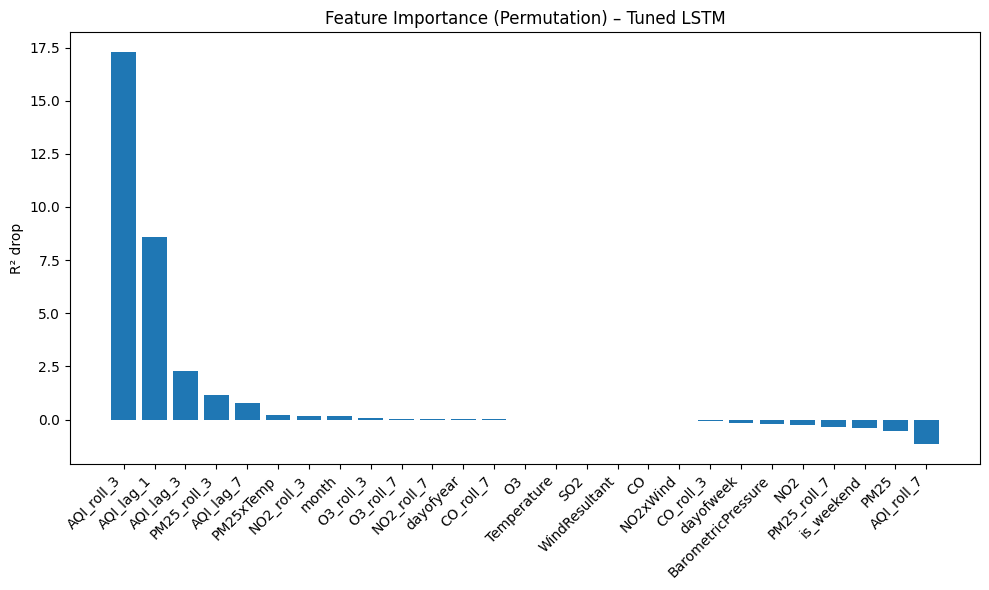

In [11]:
def permutation_importance_lstm(model, X_test, y_true, feature_names, n_repeats=3, metric=r2_score):
    """
    Permutation importance for sequence model:
    shuffle each feature across samples (same permutation applied to all time steps).
    """
    base_pred = inverse_target(model.predict(X_test))
    base_score = metric(y_true, base_pred)
    
    importances = {f: [] for f in feature_names}
    
    for j, f in enumerate(feature_names):
        for _ in range(n_repeats):
            Xp = X_test.copy()
            # shuffle along sample axis, keep time structure inside each sample
            perm = np.random.permutation(Xp.shape[0])
            Xp[:, :, j] = Xp[perm, :, j]
            
            pred_perm = inverse_target(model.predict(Xp))
            score_perm = metric(y_true, pred_perm)
            importances[f].append(base_score - score_perm)
    
    return {k: float(np.mean(v)) for k, v in importances.items()}

feat_importance = permutation_importance_lstm(
    final_model, X_test, y_test_true, FEATURES, n_repeats=3
)

imp_df = pd.DataFrame(
    sorted(feat_importance.items(), key=lambda x: x[1], reverse=True),
    columns=['Feature','Importance (ΔR²)']
)

print("\nPermutation Feature Importance (R² drop):")
print(imp_df.head(20))

# %%
plt.figure(figsize=(10,6))
plt.bar(imp_df['Feature'], imp_df['Importance (ΔR²)'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² drop')
plt.title('Feature Importance (Permutation) – Tuned LSTM')
plt.tight_layout()
plt.show()


In [20]:
X_trainval_flat = X_trainval.reshape(X_trainval.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)
feature_names_flat = [f"{f}_t-{t}" for t in range(TIME_STEPS) for f in FEATURES]

def predict_wrapper(flat_batch):
    reshaped = flat_batch.reshape(-1, TIME_STEPS, len(FEATURES))
    return final_model.predict(reshaped).flatten()

lime_explainer = lime.LimeTabularExplainer(
    training_data=X_trainval_flat,
    feature_names=feature_names_flat,
    mode='regression'
)

i = 0
exp = lime_explainer.explain_instance(
    data_row=X_test_flat[i],
    predict_fn=predict_wrapper,
    num_features=12
)

try:
    exp.show_in_notebook(show_table=True)
except Exception:
    display(HTML(exp.as_html()))

with open("exp13_lime_explanation.html", "w") as f:
    f.write(exp.as_html())

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step


 10%|█         | 1/10 [00:14<02:06, 14.08s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step


...

 80%|████████  | 8/10 [01:47<00:26, 13.40s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step


 90%|█████████ | 9/10 [02:01<00:13, 13.35s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step


100%|██████████| 10/10 [02:14<00:00, 13.49s/it]
/var/folders/rx/gyp8p3vs42zfzk_hwhrnpcmw0000gn/T/ipykernel_74655/2904406211.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, test_samples, feature_names=feature_names_flat)


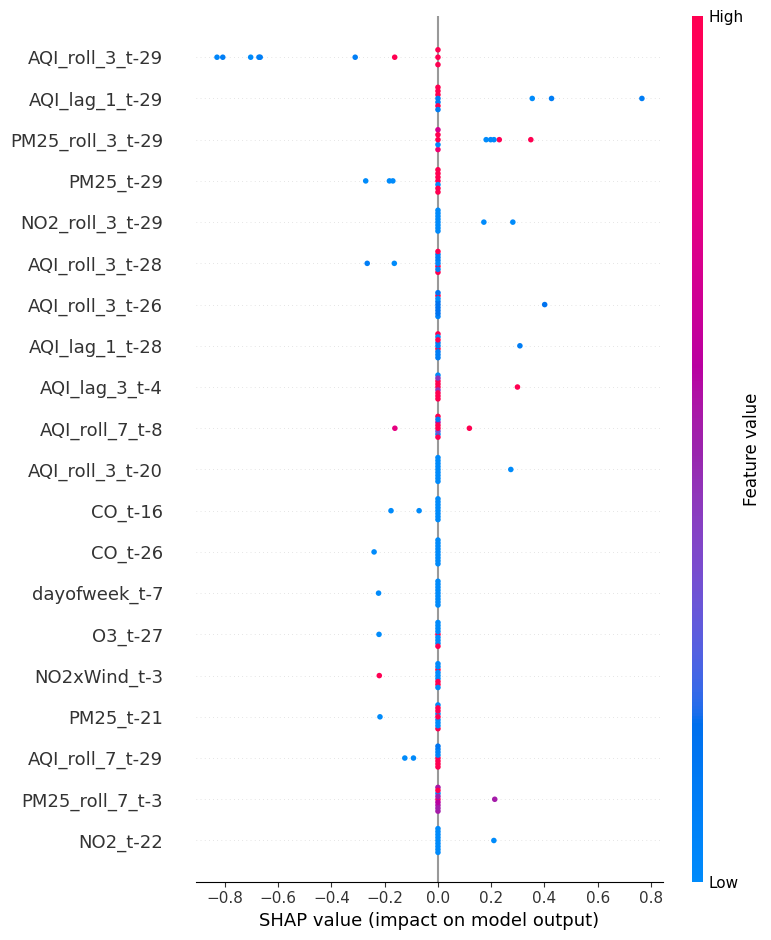

In [21]:
# Use a small random subset of train data as background for SHAP
np.random.seed(42)
n_background = min(100, X_trainval_flat.shape[0])
bg_idx = np.random.choice(X_trainval_flat.shape[0], size=n_background, replace=False)
background = X_trainval_flat[bg_idx]

# Small subset of test samples
n_test_shap = min(10, X_test_flat.shape[0])
test_samples = X_test_flat[:n_test_shap]

shap_explainer = shap.KernelExplainer(predict_wrapper, background)
shap_values = shap_explainer.shap_values(test_samples, nsamples=200)

# Summary plot (this can be a bit slow but is manageable for 10 samples)
shap.summary_plot(shap_values, test_samples, feature_names=feature_names_flat)
